## CMPINF 2100 Week 08
### KMeans with 1 variable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data

In [3]:
df = pd.read_csv('cluster_1_variable_example.csv')

In [4]:
df

,true_group,x
0,A,-1.546339
1,A,-1.775880
2,A,-1.249187
3,A,-1.677143
4,A,-2.747398
5,B,0.756365
6,B,0.679823
7,B,0.045965
8,B,0.543803
9,B,-0.687950


Let's visualize the observations using a specialized scatter plot. This scatter plot is discussed in detail in CMPINF 2130. THE STRIP PLOT

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


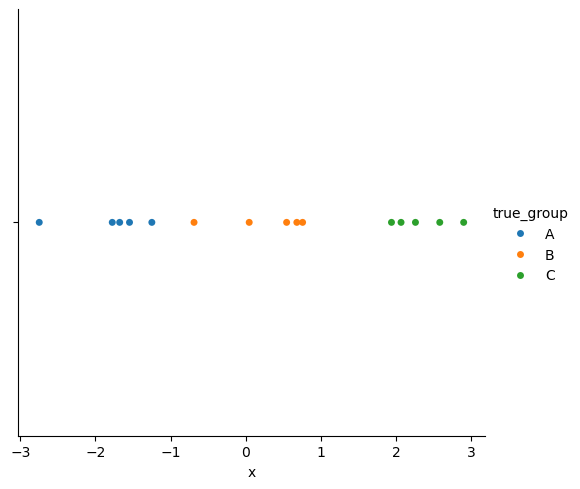

In [5]:
sns.catplot( data = df, x='x', hue='true_group', kind='strip', jitter=False)
plt.show()

Let's pretend we DO NOT know the groupings! Can we CLUSTER the observations just based on their VSLUES!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


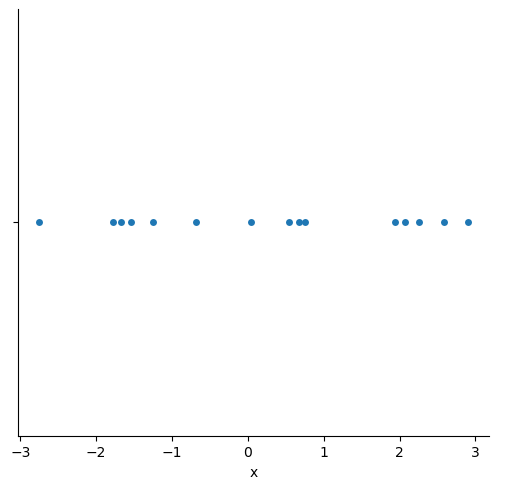

In [6]:
sns.catplot( data = df, x='x', kind='strip', jitter=False)
plt.show()

## KMeans

But before we can RUN KMeans...we need to organize the data appropriately. The function we will use WANTS NumPy arrays and NOT Pandas DataFrames. 

The DataFrames NEEDS to be a 2D array.

In [7]:
df.x.to_numpy()

array([-1.54633927, -1.77588013, -1.24918706, -1.67714288, -2.74739841,
        0.75636481,  0.67982292,  0.04596469,  0.54380312, -0.68795048,
        2.58130181,  2.25782372,  1.93887976,  2.89935259,  2.06605957])

In [8]:
df.x.to_numpy().reshape(-1,1)

array([[-1.54633927],
       [-1.77588013],
       [-1.24918706],
       [-1.67714288],
       [-2.74739841],
       [ 0.75636481],
       [ 0.67982292],
       [ 0.04596469],
       [ 0.54380312],
       [-0.68795048],
       [ 2.58130181],
       [ 2.25782372],
       [ 1.93887976],
       [ 2.89935259],
       [ 2.06605957]])

In [9]:
X = df.x.to_numpy().reshape(-1,1)

In [10]:
X.ndim

2

In [11]:
X.shape

(15, 1)

In [12]:
X

array([[-1.54633927],
       [-1.77588013],
       [-1.24918706],
       [-1.67714288],
       [-2.74739841],
       [ 0.75636481],
       [ 0.67982292],
       [ 0.04596469],
       [ 0.54380312],
       [-0.68795048],
       [ 2.58130181],
       [ 2.25782372],
       [ 1.93887976],
       [ 2.89935259],
       [ 2.06605957]])

The FUNCTION to execute KMeans comes from the scikit-learn MODULE. scikit-learn is RARELY imported directly. Instead, we IMPORT FUNCTIONS from scikit-learn.

The function is named KMeans() and it comes from the `sklearn.cluster` module

In [13]:
from sklearn.cluster import KMeans

In [15]:
%whos

Variable   Type         Data/Info
---------------------------------
KMeans     ABCMeta      <class 'sklearn.cluster._kmeans.KMeans'>
X          ndarray      15x1: 15 elems, type `float64`, 120 bytes
df         DataFrame       true_group         x\n<...>\n14          C  2.066060
np         module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
pd         module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>


ALL functions from scikit-learn follow the following recipe:
* INITIALIZE the object - specify the ASSUMPTIONS for how the method is executed
* FIT the Object - LEARN what you need to learn
* PREDICT or TRANSFORM - return the VALUES you want from a FITTED object

Let's begin by INITIALIZING. The ASSUMPTION ARE:
* The number of clusters
* The random seed which controls the randomness - the initial guess
* The number of initial guesses
* The number of iterations for each initial guess

Let's begin with 3 clusters since we know there are in fact 3 groups in this small application

In [16]:
km3 = KMeans(n_clusters=3, random_state=121, n_init = 25, max_iter=500)

In [17]:
type(km3)

sklearn.cluster._kmeans.KMeans

We have not provided any DATA when we INITIALIZE!

We give the data when we FIT the object using the assumptions

In [18]:
km3 = km3.fit( X )

For KMeans FITTING means it identified the CLUSTERS associated with EACH data point!

To RETURN the CLUSTER ASSIGNMENT or CLUSTER LABELS we need to PREDICT the data!!!